# 实验：已知动力学下的 transport map 协同验证

这个 notebook 不再比较 `nis` 和 `tm` 两种方法，而是只保留 `transport map` 这条路线。目标是在已知动力学下，检验用 `TM` 估计 `EI` 再计算 `syn` 是否能恢复我们人为注入的协同结构。

这里把协同机制压缩成单个参数 `alpha`：

- `alpha = 0` 时，目标退化成单源加性结构，预期 `syn` 接近 `0`；
- `alpha` 从 `0` 增大到 `1` 时，联合项逐步增强，预期 `syn` 上升；
- 同时观察整体 `EI` 与单源 `EI` 的变化，判断信息是如何从单源解释转移到联合协同结构中的。

最终输出保留 `alpha` 汇总表、因子图风格的案例示意图、低噪声 `EI` 分解图、`Syn / EI` 和单源占比图，并补充一个高噪声 `EI` 分解图用于文档对照。


In [7]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path
from typing import Any

os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MPLCONFIGDIR', str((Path.cwd().resolve() / 'tmp' / 'matplotlib').resolve()))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / 'utils.py').exists():
        candidate_str = str(candidate)
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate project root from current working directory.')

from yrd.transport_map import summarize_two_source_synergy_transport_map

SEED = 11
pd.set_option('display.max_columns', None)


## 实验设定

固定两个源变量服从同一个均匀干预分布：

\[
Q_2^n, Q_3^n \sim \mathrm{Uniform}[-L/2, L/2].
\]

目标变量采用已知动力学：

\[
Q_1^{n+1} = \alpha \, \sin(Q_2^n Q_3^n) + (1-\alpha) Q_2^n + \varepsilon, \quad \alpha \in [0, 1].
\]

这里 `alpha` 就是我们主动设定的结构参数：

- `alpha = 0` 时，`Q_1^{n+1}` 只依赖 `Q_2^n`，所以 `syn` 应接近 `0`；
- `alpha` 增大时，联合非线性项 `\sin(Q_2^n Q_3^n)` 逐步替代单源加性项，协同应变强；
- `Q_3^n` 单独看仍可能几乎没有解释力，因为它主要通过联合结构起作用。

下面先画一张因子图风格的案例示意图，再沿着 `alpha` 网格重复采样，调用 `transport map` 汇总 `EI^tm`、`Syn^tm` 和两个单源 `EI`，然后看这些量是否符合已知动力学。


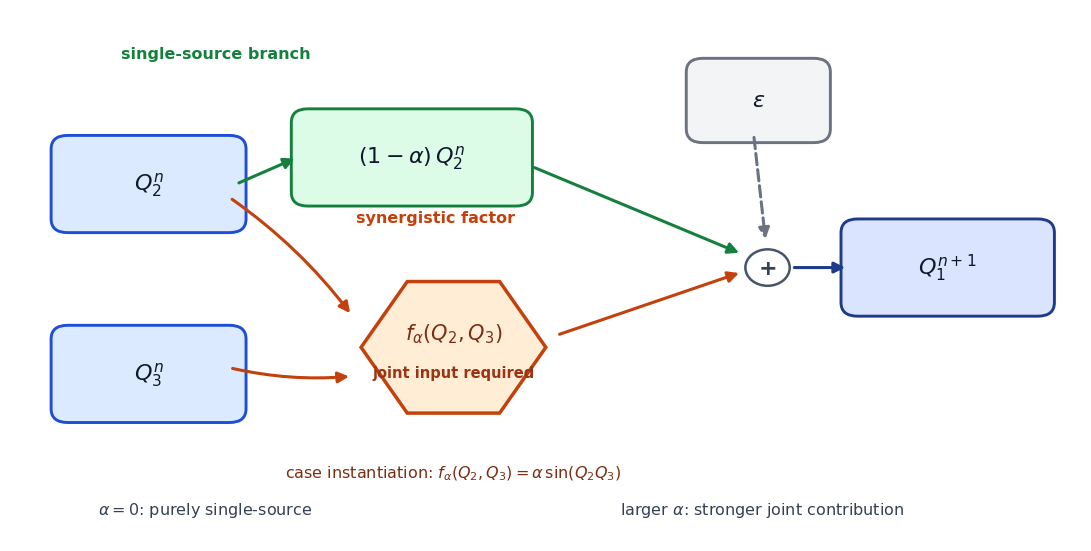

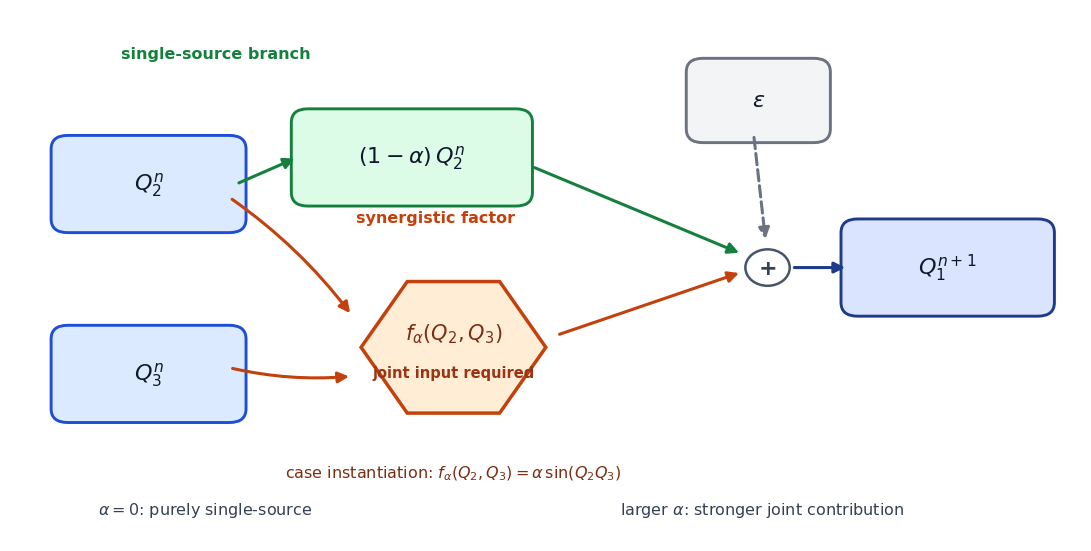

In [8]:
def draw_alpha_case_factor_graph() -> Any:
    from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch, RegularPolygon

    output_dir = PROJECT_ROOT / 'fig' / 'transport_map_mutual_information'
    output_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(10.8, 5.4), constrained_layout=True)
    ax.set_xlim(0.0, 11.6)
    ax.set_ylim(0.0, 7.0)
    ax.axis('off')

    variable_fill = '#dbeafe'
    variable_edge = '#1d4ed8'
    additive_fill = '#dcfce7'
    additive_edge = '#15803d'
    factor_fill = '#ffedd5'
    factor_edge = '#c2410c'
    target_fill = '#dbe4ff'
    target_edge = '#1e3a8a'
    noise_fill = '#f3f4f6'
    noise_edge = '#6b7280'

    def add_variable_node(center: tuple[float, float], label: str, *, fill: str = variable_fill, edge: str = variable_edge, width: float = 1.75, height: float = 0.92) -> None:
        x, y = center
        patch = FancyBboxPatch(
            (x - width / 2.0, y - height / 2.0),
            width,
            height,
            boxstyle='round,pad=0.18,rounding_size=0.18',
            linewidth=2.1,
            facecolor=fill,
            edgecolor=edge,
        )
        ax.add_patch(patch)
        ax.text(x, y, label, ha='center', va='center', fontsize=16, color='#0f172a')

    def add_arrow(start: tuple[float, float], end: tuple[float, float], *, color: str, lw: float = 2.2, style: str = '-', rad: float = 0.0) -> None:
        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle='-|>',
            mutation_scale=16,
            linewidth=lw,
            linestyle=style,
            color=color,
            connectionstyle=f'arc3,rad={rad}',
        )
        ax.add_patch(arrow)

    q2_center = (1.5, 4.7)
    q3_center = (1.5, 2.2)
    additive_center = (4.35, 5.05)
    factor_center = (4.8, 2.55)
    sum_center = (8.2, 3.6)
    target_center = (10.15, 3.6)
    noise_center = (8.1, 5.8)

    add_variable_node(q2_center, r'$Q_2^n$')
    add_variable_node(q3_center, r'$Q_3^n$')
    add_variable_node(additive_center, r'$(1-\alpha)\,Q_2^n$', fill=additive_fill, edge=additive_edge, width=2.25)
    add_variable_node(target_center, r'$Q_1^{n+1}$', fill=target_fill, edge=target_edge, width=1.95)
    add_variable_node(noise_center, r'$\varepsilon$', fill=noise_fill, edge=noise_edge, width=1.2, height=0.75)

    factor = RegularPolygon(
        factor_center,
        numVertices=6,
        radius=1.0,
        orientation=np.pi / 6.0,
        facecolor=factor_fill,
        edgecolor=factor_edge,
        linewidth=2.5,
    )
    ax.add_patch(factor)
    ax.text(factor_center[0], factor_center[1] + 0.18, r'$f_{\alpha}(Q_2, Q_3)$', ha='center', va='center', fontsize=15, color='#7c2d12')
    ax.text(factor_center[0], factor_center[1] - 0.34, 'joint input required', ha='center', va='center', fontsize=10.5, color='#9a3412', fontweight='semibold')
    ax.text(factor_center[0], 0.9, r'case instantiation: $f_{\alpha}(Q_2, Q_3) = \alpha\,\sin(Q_2 Q_3)$', ha='center', va='center', fontsize=11.5, color='#7c2d12')

    sum_node = Circle(sum_center, radius=0.24, facecolor='white', edgecolor='#475569', linewidth=1.8)
    ax.add_patch(sum_node)
    ax.text(sum_center[0], sum_center[1] - 0.01, '+', ha='center', va='center', fontsize=16, color='#334155', fontweight='bold')

    add_arrow((q2_center[0] + 0.95, q2_center[1]), (additive_center[0] - 1.24, additive_center[1]), color=additive_edge)
    add_arrow((q2_center[0] + 0.88, q2_center[1] - 0.18), (factor_center[0] - 1.1, factor_center[1] + 0.42), color=factor_edge, rad=-0.08)
    add_arrow((q3_center[0] + 0.88, q3_center[1] + 0.08), (factor_center[0] - 1.1, factor_center[1] - 0.38), color=factor_edge, rad=0.08)
    add_arrow((additive_center[0] + 1.3, additive_center[1] - 0.12), (sum_center[0] - 0.28, sum_center[1] + 0.18), color=additive_edge)
    add_arrow((factor_center[0] + 1.12, factor_center[1] + 0.16), (sum_center[0] - 0.28, sum_center[1] - 0.06), color=factor_edge)
    add_arrow((noise_center[0] - 0.05, noise_center[1] - 0.45), (sum_center[0] - 0.02, sum_center[1] + 0.34), color=noise_edge, style='--')
    add_arrow((sum_center[0] + 0.26, sum_center[1]), (target_center[0] - 1.08, target_center[1]), color=target_edge)

    ax.text(1.2, 6.35, 'single-source branch', fontsize=11.5, color=additive_edge, fontweight='semibold')
    ax.text(3.75, 4.2, 'synergistic factor', fontsize=11.5, color=factor_edge, fontweight='semibold')
    ax.text(0.95, 0.35, r'$\alpha = 0$: purely single-source', fontsize=11.5, color='#334155')
    ax.text(6.6, 0.35, r'larger $\alpha$: stronger joint contribution', fontsize=11.5, color='#334155')

    figure_path = output_dir / 'tm_alpha_factor_graph.png'
    fig.savefig(figure_path, dpi=240, bbox_inches='tight')
    return fig


draw_alpha_case_factor_graph()


In [ ]:
ALPHA_VALUES = (0.0, 0.2, 0.4, 0.6, 0.8, 1.0)
INPUT_BOX_WIDTH = 2.0
N_SAMPLES = 4000
REPEATS = 4
Q1_NOISE_STD = 0.05


def simulate_alpha_case_intervention(
    *,
    alpha: float,
    n_samples: int = N_SAMPLES,
    L: float = INPUT_BOX_WIDTH,
    q1_noise_std: float = Q1_NOISE_STD,
    seed: int = 0,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    half = float(L) / 2.0
    q2_t = rng.uniform(-half, half, size=n_samples)
    q3_t = rng.uniform(-half, half, size=n_samples)
    q1_next = alpha * np.sin(q2_t * q3_t) + (1.0 - alpha) * q2_t + float(q1_noise_std) * rng.normal(size=n_samples)
    return pd.DataFrame(
        {
            'alpha': float(alpha),
            'q2_t': q2_t,
            'q3_t': q3_t,
            'q1_next': q1_next,
        }
    )


def estimate_tm_alpha_metrics(df: pd.DataFrame) -> dict[str, float]:
    summary = summarize_two_source_synergy_transport_map(
        df[['q2_t']].to_numpy(),
        df[['q3_t']].to_numpy(),
        df[['q1_next']].to_numpy(),
    )
    return {
        'tm_ei': float(summary['joint_ei']),
        'tm_syn': float(summary['syn']),
        'tm_single_q2': float(summary['left_ei']),
        'tm_single_q3': float(summary['right_ei']),
    }


def run_alpha_sweep_tm(
    *,
    alpha_values: tuple[float, ...] = ALPHA_VALUES,
    n_samples: int = N_SAMPLES,
    repeats: int = REPEATS,
    L: float = INPUT_BOX_WIDTH,
    q1_noise_std: float = Q1_NOISE_STD,
    seed: int = SEED,
) -> pd.DataFrame:
    rows: list[dict[str, float | int]] = []
    for alpha_index, alpha in enumerate(alpha_values):
        for repeat in range(repeats):
            run_seed = seed + 1000 * alpha_index + repeat
            df = simulate_alpha_case_intervention(
                alpha=float(alpha),
                n_samples=n_samples,
                L=L,
                q1_noise_std=q1_noise_std,
                seed=run_seed,
            )
            tm_metrics = estimate_tm_alpha_metrics(df)
            rows.append(
                {
                    'alpha': float(alpha),
                    'repeat': int(repeat),
                    'L': float(L),
                    'q1_noise_std': float(q1_noise_std),
                    'tm_ei': tm_metrics['tm_ei'],
                    'tm_syn': tm_metrics['tm_syn'],
                    'tm_single_q2': tm_metrics['tm_single_q2'],
                    'tm_single_q3': tm_metrics['tm_single_q3'],
                }
            )
    return pd.DataFrame(rows)


def summarize_alpha_sweep_tm(results_df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        results_df.groupby(['alpha', 'L', 'q1_noise_std'], as_index=False)
        .agg(
            tm_ei_mean=('tm_ei', 'mean'),
            tm_ei_std=('tm_ei', 'std'),
            tm_syn_mean=('tm_syn', 'mean'),
            tm_syn_std=('tm_syn', 'std'),
            tm_single_q2_mean=('tm_single_q2', 'mean'),
            tm_single_q2_std=('tm_single_q2', 'std'),
            tm_single_q3_mean=('tm_single_q3', 'mean'),
            tm_single_q3_std=('tm_single_q3', 'std'),
        )
        .sort_values('alpha')
        .reset_index(drop=True)
    )
    summary['tm_syn_ratio'] = np.where(
        np.abs(summary['tm_ei_mean']) > 1e-12,
        summary['tm_syn_mean'] / summary['tm_ei_mean'],
        np.nan,
    )
    summary['tm_single_q2_ratio'] = np.where(
        np.abs(summary['tm_ei_mean']) > 1e-12,
        summary['tm_single_q2_mean'] / summary['tm_ei_mean'],
        np.nan,
    )
    summary['tm_single_q3_ratio'] = np.where(
        np.abs(summary['tm_ei_mean']) > 1e-12,
        summary['tm_single_q3_mean'] / summary['tm_ei_mean'],
        np.nan,
    )
    return summary


alpha_tm_results = run_alpha_sweep_tm()
alpha_tm_summary = summarize_alpha_sweep_tm(alpha_tm_results)
alpha_tm_summary


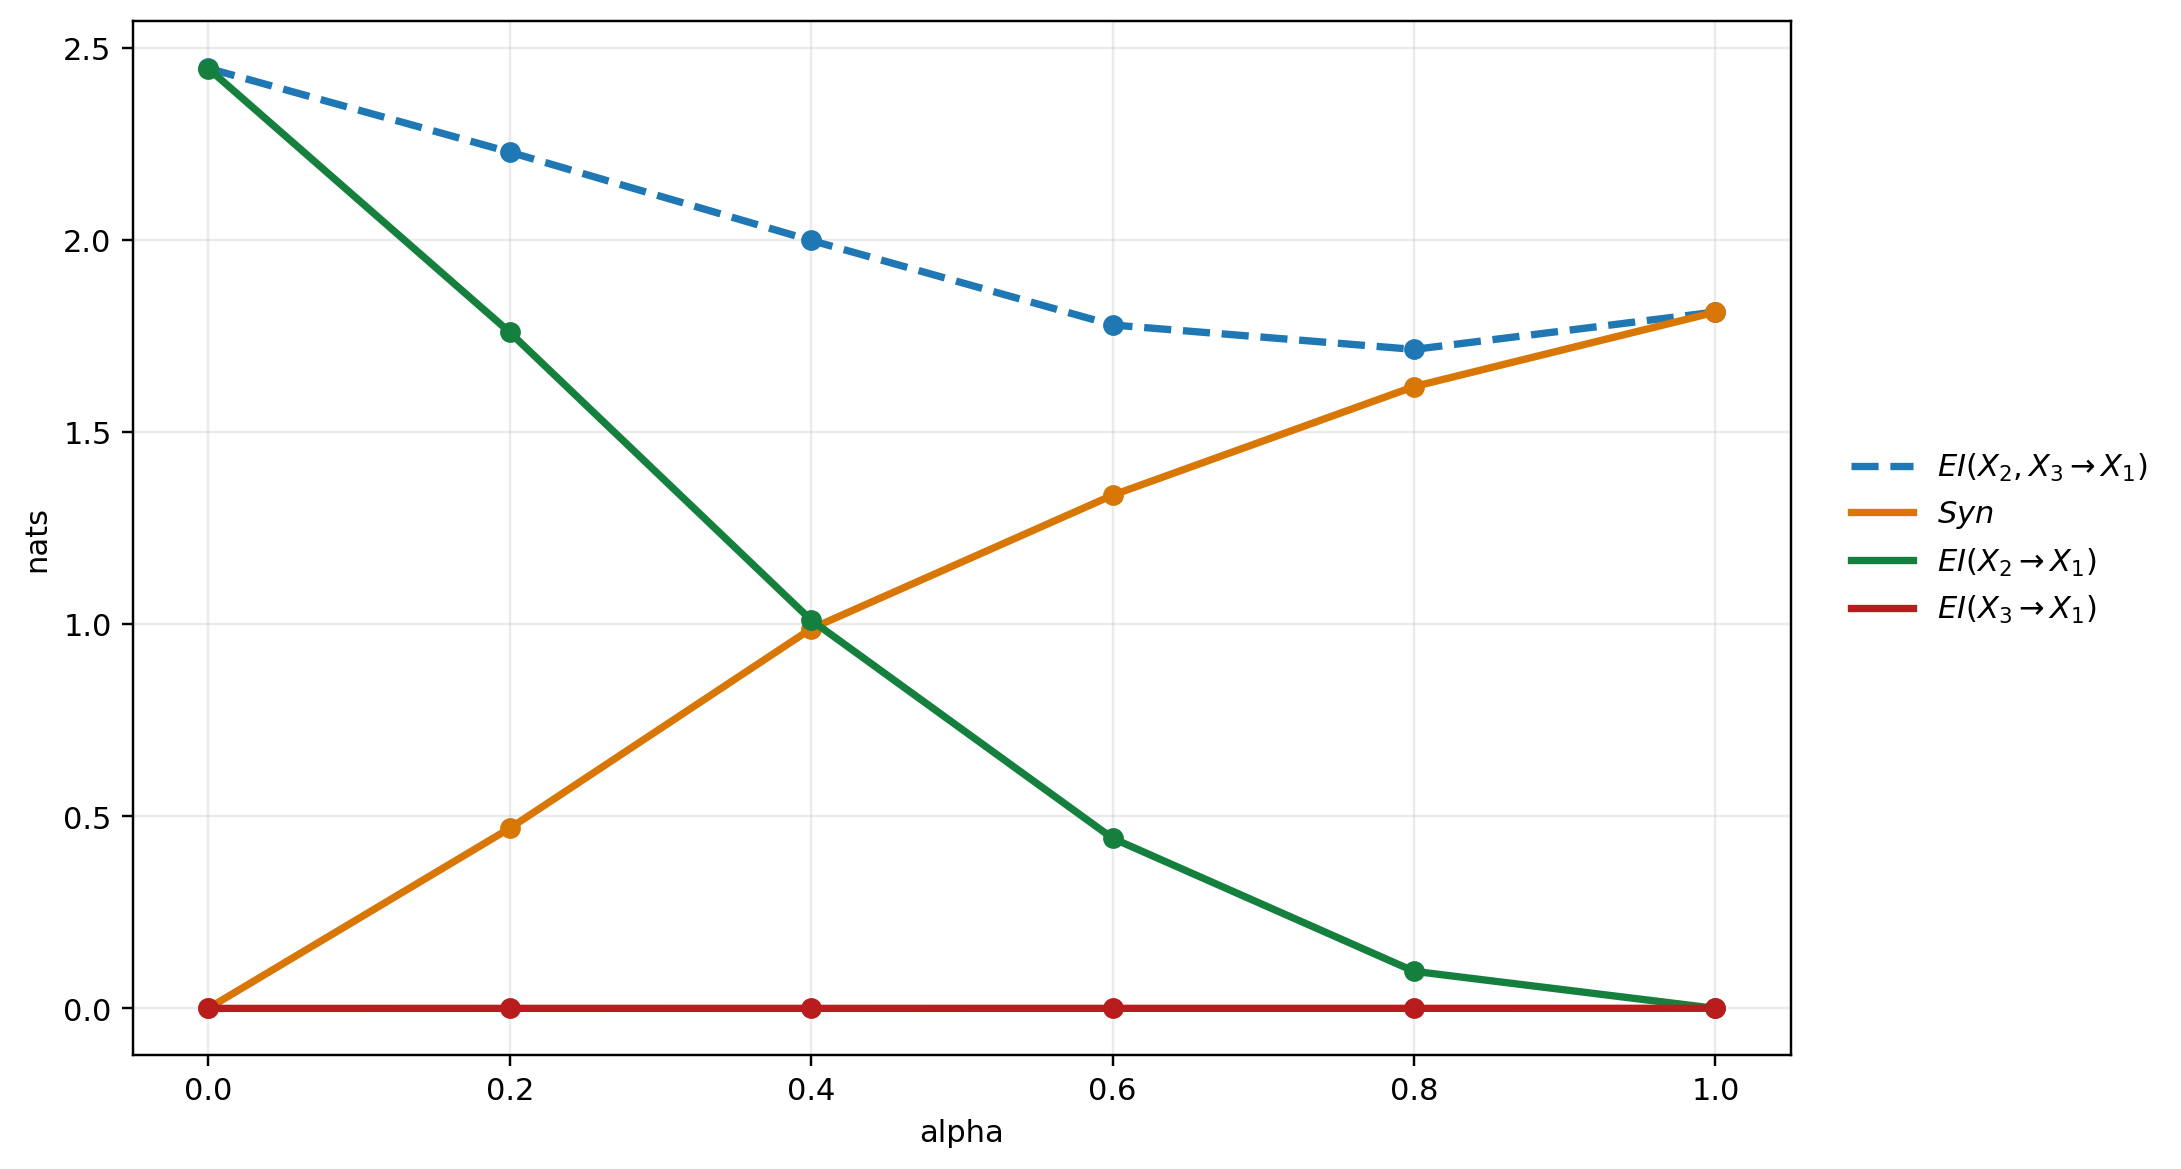

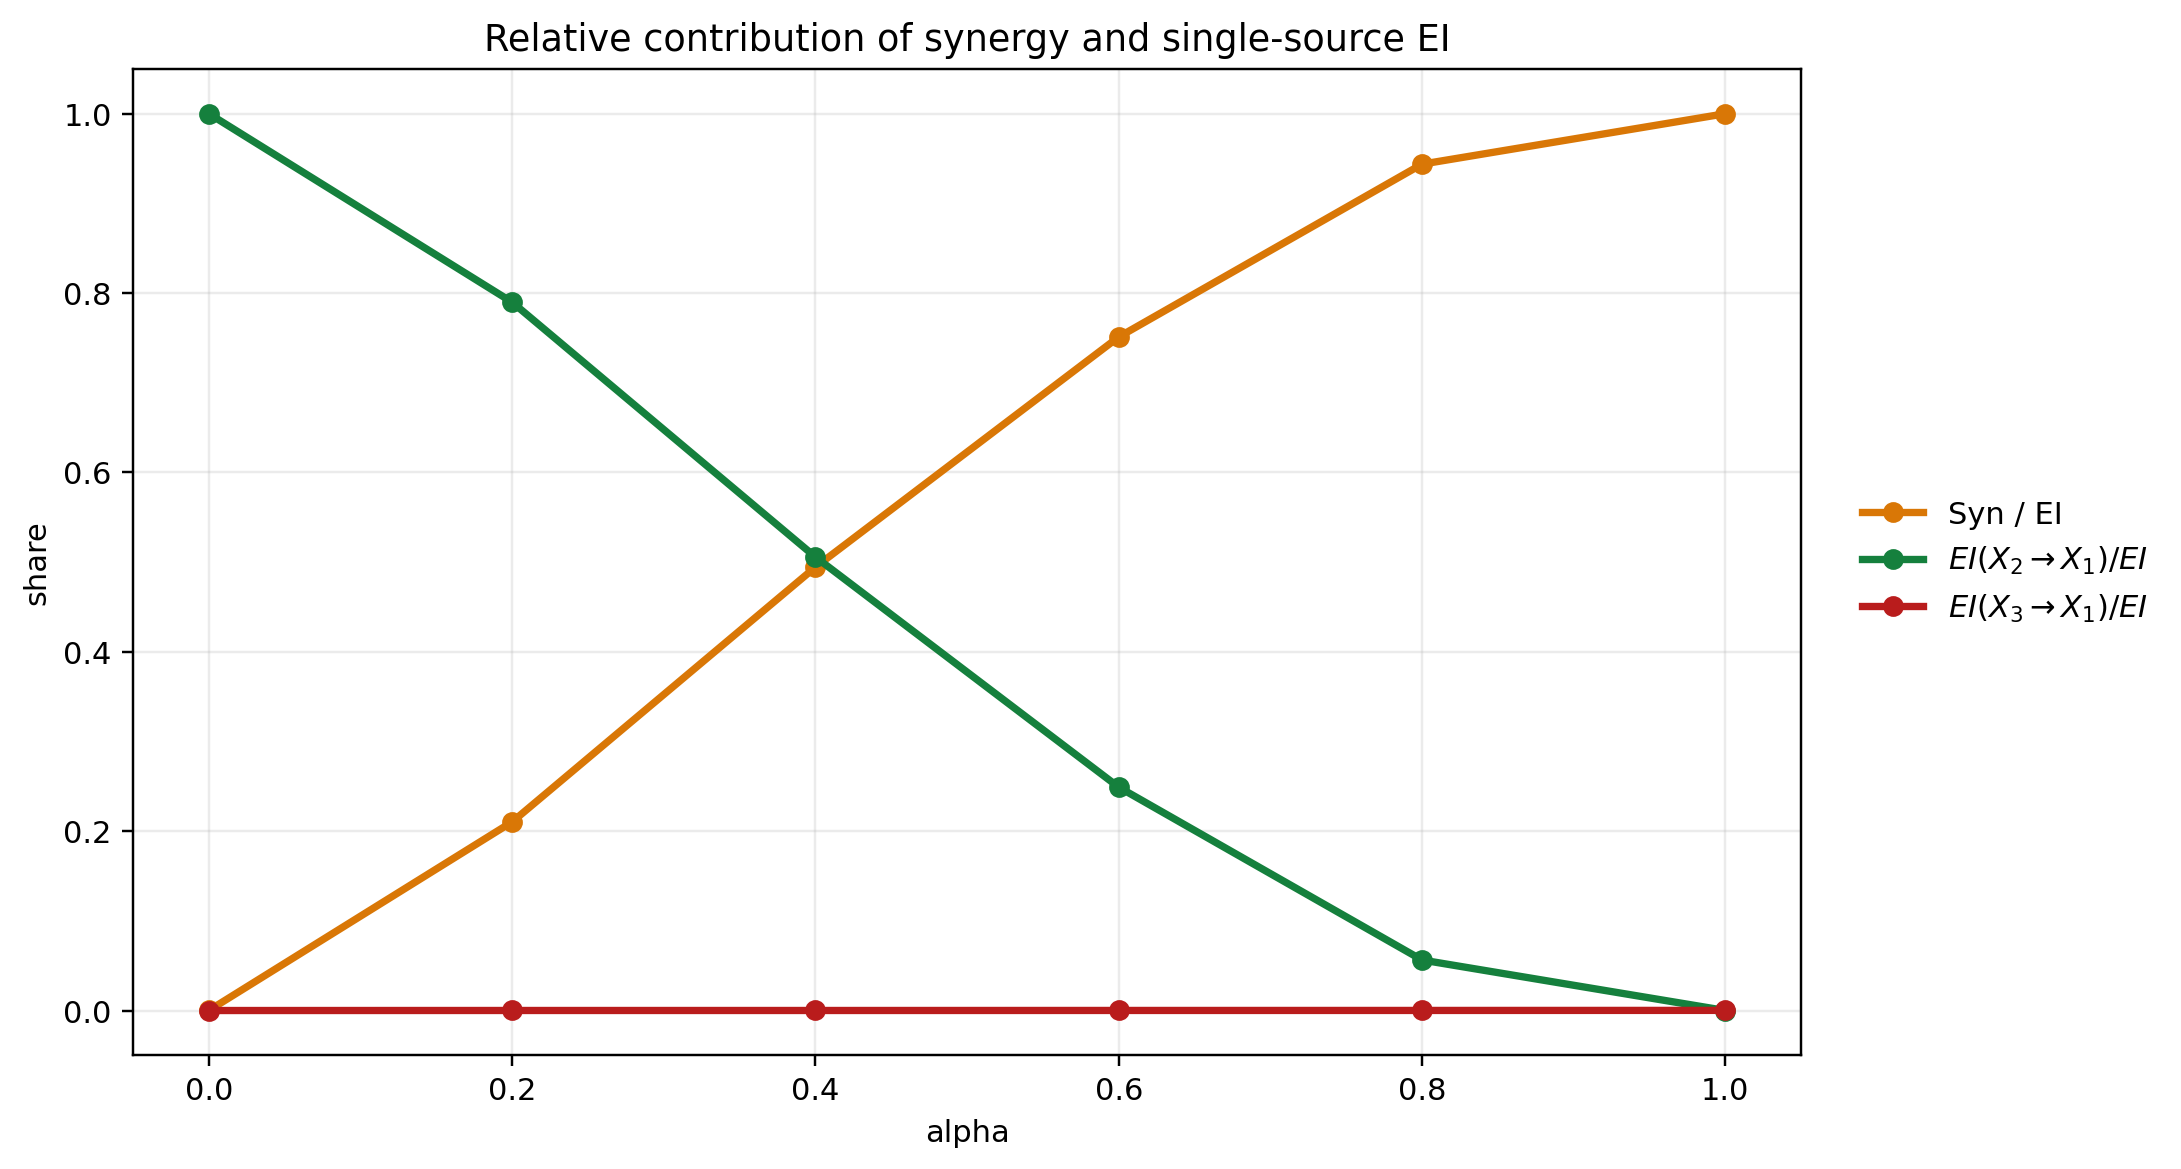

In [ ]:
def plot_alpha_sweep_tm(summary_df: pd.DataFrame) -> tuple[Any, Any]:
    from matplotlib.lines import Line2D
    output_dir = PROJECT_ROOT / 'fig' / 'transport_map_mutual_information'
    output_dir.mkdir(parents=True, exist_ok=True)

    color_ei = '#1f77b4'
    color_syn = '#d97706'
    color_q2 = '#15803d'
    color_q3 = '#b91c1c'
    line_width = 2.4
    marker_size = 5.8

    decomp_fig, decomp_ax = plt.subplots(figsize=(9.8, 5.2), constrained_layout=True)
    decomp_ax.plot(summary_df['alpha'], summary_df['tm_ei_mean'], marker='o', markersize=marker_size, linewidth=line_width, linestyle='--', color=color_ei, label=r'$EI(X_2, X_3 \to X_1)$')
    decomp_ax.plot(summary_df['alpha'], summary_df['tm_syn_mean'], marker='o', markersize=marker_size, linewidth=line_width, linestyle='-', color=color_syn, label=r'$Syn$')
    decomp_ax.plot(summary_df['alpha'], summary_df['tm_single_q2_mean'], marker='o', markersize=marker_size, linewidth=line_width, linestyle='-', color=color_q2, label=r'$EI(X_2 \to X_1)$')
    decomp_ax.plot(summary_df['alpha'], summary_df['tm_single_q3_mean'], marker='o', markersize=marker_size, linewidth=line_width, linestyle='-', color=color_q3, label=r'$EI(X_3 \to X_1)$')
    decomp_ax.set_xlabel('alpha')
    decomp_ax.set_ylabel('nats')
    decomp_ax.set_xticks(summary_df['alpha'])
    decomp_ax.grid(alpha=0.25)
    decomp_handles = [
        Line2D([0], [0], color=color_ei, linestyle='--', linewidth=line_width, label=r'$EI(X_2, X_3 \to X_1)$'),
        Line2D([0], [0], color=color_syn, linestyle='-', linewidth=line_width, label=r'$Syn$'),
        Line2D([0], [0], color=color_q2, linestyle='-', linewidth=line_width, label=r'$EI(X_2 \to X_1)$'),
        Line2D([0], [0], color=color_q3, linestyle='-', linewidth=line_width, label=r'$EI(X_3 \to X_1)$'),
    ]
    decomp_ax.legend(handles=decomp_handles, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    share_fig, share_ax = plt.subplots(figsize=(9.8, 5.2), constrained_layout=True)
    share_ax.plot(summary_df['alpha'], summary_df['tm_syn_ratio'], marker='o', markersize=marker_size, linewidth=line_width, color=color_syn, label='Syn / EI')
    share_ax.plot(summary_df['alpha'], summary_df['tm_single_q2_ratio'], marker='o', markersize=marker_size, linewidth=line_width, color=color_q2, label=r'$EI(X_2 \to X_1) / EI$')
    share_ax.plot(summary_df['alpha'], summary_df['tm_single_q3_ratio'], marker='o', markersize=marker_size, linewidth=line_width, color=color_q3, label=r'$EI(X_3 \to X_1) / EI$')
    share_ax.set_xlabel('alpha')
    share_ax.set_ylabel('share')
    share_ax.set_title('Relative contribution of synergy and single-source EI')
    share_ax.set_xticks(summary_df['alpha'])
    share_ax.set_ylim(-0.05, 1.05)
    share_ax.grid(alpha=0.25)
    share_ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    decomp_path = output_dir / 'tm_alpha_ei_decomposition.png'
    share_path = output_dir / 'tm_alpha_share_ratio.png'
    summary_path = output_dir / 'tm_alpha_summary.csv'
    manifest_path = output_dir / 'tm_alpha_manifest.json'

    decomp_fig.savefig(decomp_path, dpi=220, bbox_inches='tight')
    share_fig.savefig(share_path, dpi=220, bbox_inches='tight')
    summary_df.to_csv(summary_path, index=False)
    manifest_path.write_text(
        json.dumps(
            {
                'notebook': 'exp/tm_nonlinear.ipynb',
                'alpha_values': list(summary_df['alpha']),
                'figures': ['tm_alpha_factor_graph.png', decomp_path.name, share_path.name],
                'summary_csv': summary_path.name,
            },
            ensure_ascii=False,
            indent=2,
        ),
        encoding='utf-8',
    )
    return decomp_fig, share_fig


plot_alpha_sweep_tm(alpha_tm_summary)


## 外部噪声强度对照

为了把机制强度和外部观测噪声分开，这里保持 `alpha`、`L`、样本数和重复次数不变，只把目标变量的外部噪声从 `0.05` 增大到 `0.6`。高噪声结果用于和前面的低噪声分解图并列写入研究框架文档。


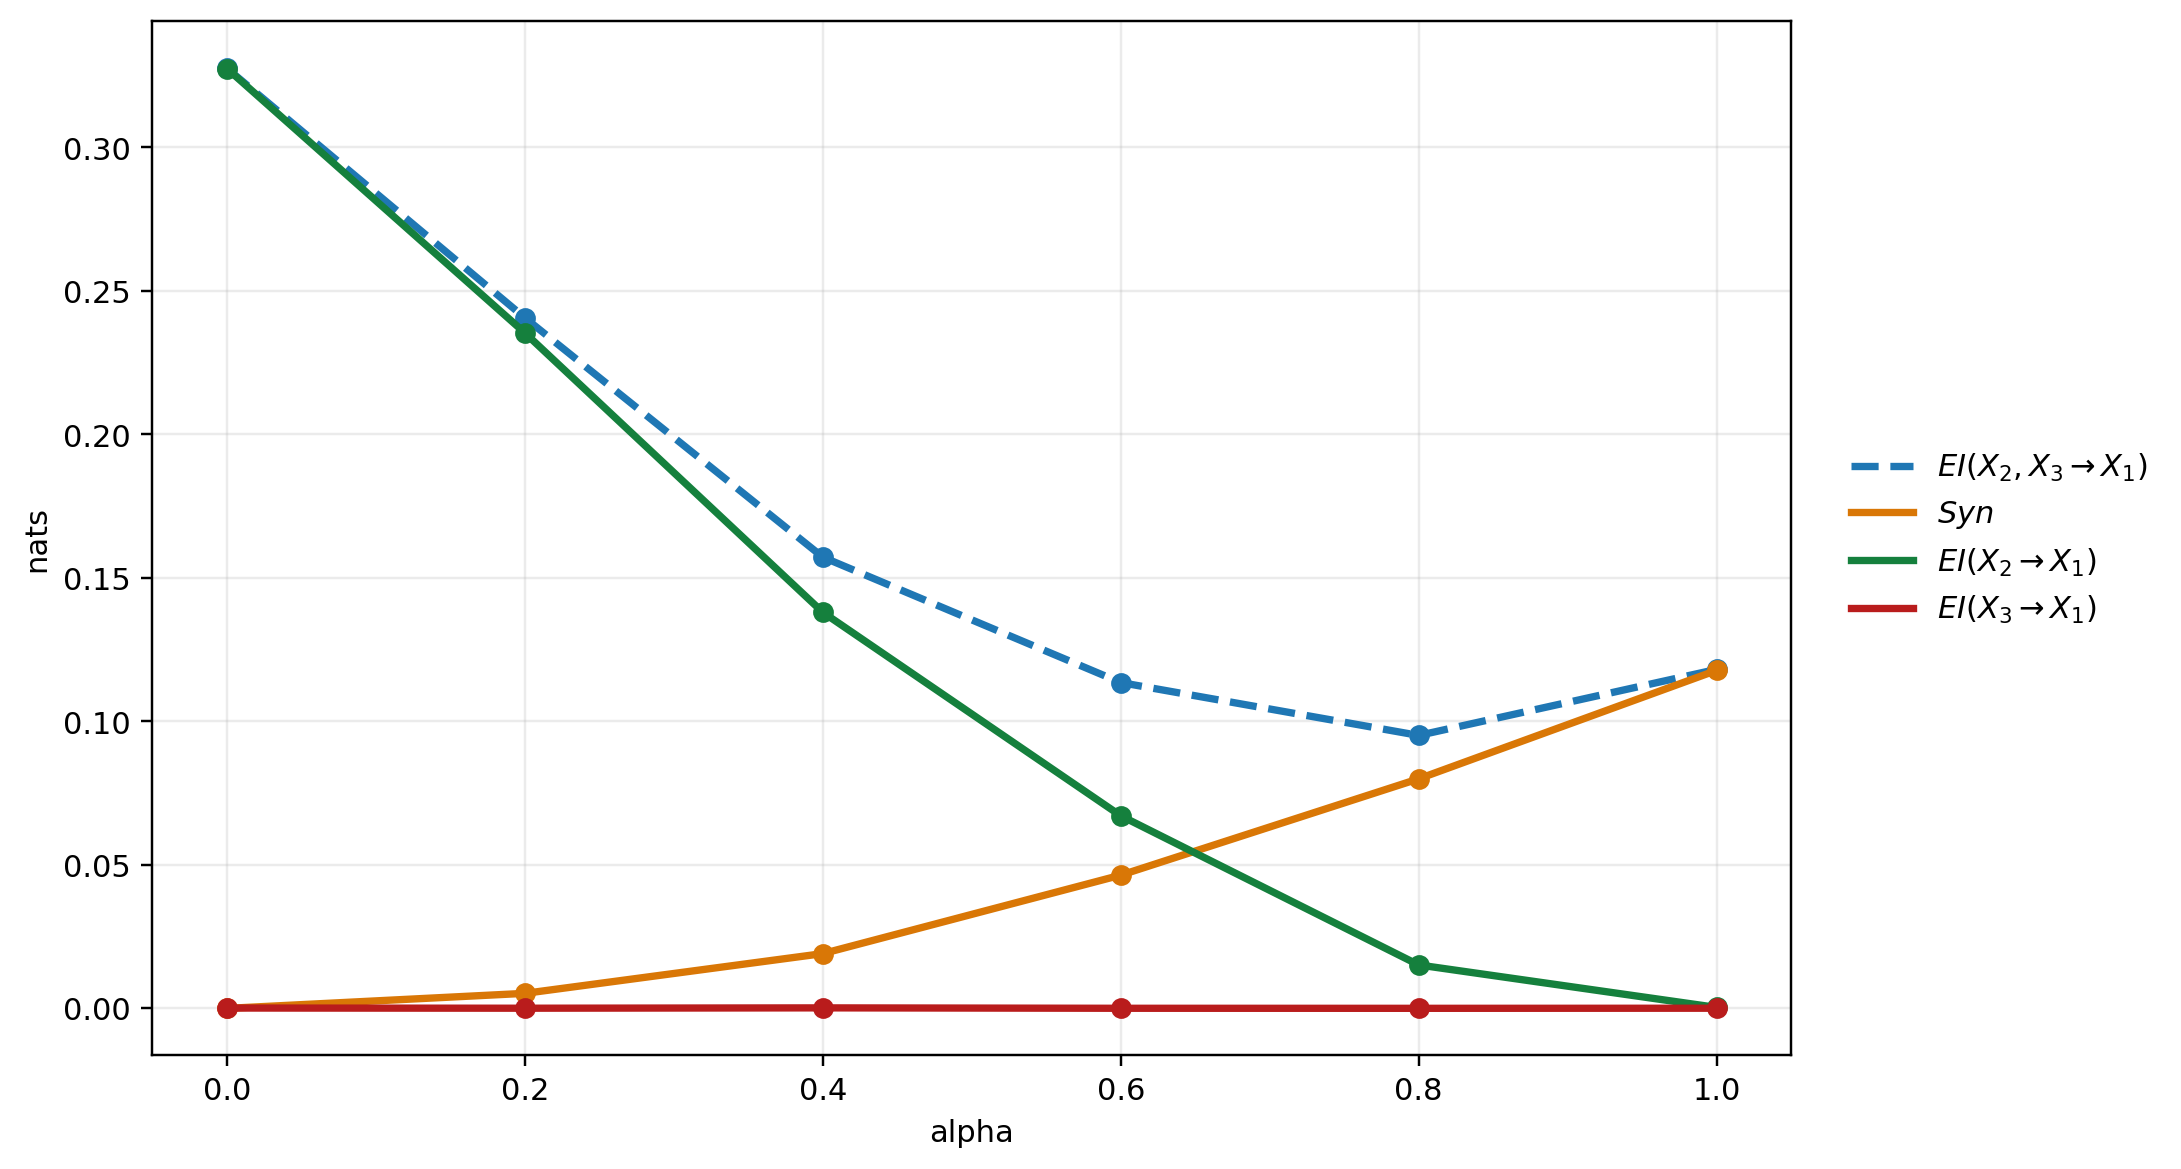

In [ ]:
HIGH_NOISE_STD = 0.6


def plot_alpha_high_noise_decomposition(summary_df: pd.DataFrame) -> Any:
    from matplotlib.lines import Line2D

    output_dir = PROJECT_ROOT / 'fig' / 'transport_map_mutual_information'
    output_dir.mkdir(parents=True, exist_ok=True)

    color_ei = '#1f77b4'
    color_syn = '#d97706'
    color_q2 = '#15803d'
    color_q3 = '#b91c1c'
    line_width = 2.4
    marker_size = 5.8

    fig, ax = plt.subplots(figsize=(9.8, 5.2), constrained_layout=True)
    ax.plot(summary_df['alpha'], summary_df['tm_ei_mean'], marker='o', markersize=marker_size, linewidth=line_width, linestyle='--', color=color_ei, label=r'$EI(X_2, X_3 	o X_1)$')
    ax.plot(summary_df['alpha'], summary_df['tm_syn_mean'], marker='o', markersize=marker_size, linewidth=line_width, linestyle='-', color=color_syn, label=r'$Syn$')
    ax.plot(summary_df['alpha'], summary_df['tm_single_q2_mean'], marker='o', markersize=marker_size, linewidth=line_width, linestyle='-', color=color_q2, label=r'$EI(X_2 	o X_1)$')
    ax.plot(summary_df['alpha'], summary_df['tm_single_q3_mean'], marker='o', markersize=marker_size, linewidth=line_width, linestyle='-', color=color_q3, label=r'$EI(X_3 	o X_1)$')
    ax.set_xlabel('alpha')
    ax.set_ylabel('nats')
    ax.set_xticks(summary_df['alpha'])
    ax.grid(alpha=0.25)
    handles = [
        Line2D([0], [0], color=color_ei, linestyle='--', linewidth=line_width, label=r'$EI(X_2, X_3 	o X_1)$'),
        Line2D([0], [0], color=color_syn, linestyle='-', linewidth=line_width, label=r'$Syn$'),
        Line2D([0], [0], color=color_q2, linestyle='-', linewidth=line_width, label=r'$EI(X_2 	o X_1)$'),
        Line2D([0], [0], color=color_q3, linestyle='-', linewidth=line_width, label=r'$EI(X_3 	o X_1)$'),
    ]
    ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    png_path = output_dir / 'tm_alpha_high_noise_ei_decomposition.png'
    pdf_path = output_dir / 'tm_alpha_high_noise_ei_decomposition.pdf'
    fig.savefig(png_path, dpi=220, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    return fig


high_noise_output_dir = PROJECT_ROOT / 'fig' / 'transport_map_mutual_information'
high_noise_runs_path = high_noise_output_dir / 'tm_alpha_high_noise_runs.csv'
high_noise_summary_path = high_noise_output_dir / 'tm_alpha_high_noise_summary.csv'
high_noise_manifest_path = high_noise_output_dir / 'tm_alpha_high_noise_manifest.json'

if high_noise_summary_path.exists() and high_noise_runs_path.exists():
    high_noise_results = pd.read_csv(high_noise_runs_path)
    high_noise_summary = pd.read_csv(high_noise_summary_path)
else:
    high_noise_results = run_alpha_sweep_tm(q1_noise_std=HIGH_NOISE_STD, seed=SEED + 50000)
    high_noise_summary = summarize_alpha_sweep_tm(high_noise_results)
    high_noise_results.to_csv(high_noise_runs_path, index=False)
    high_noise_summary.to_csv(high_noise_summary_path, index=False)

high_noise_manifest_path.write_text(
    json.dumps(
        {
            'notebook': 'exp/tm_nonlinear.ipynb',
            'alpha_values': list(high_noise_summary['alpha']),
            'q1_noise_std': HIGH_NOISE_STD,
            'runs_csv': high_noise_runs_path.name,
            'summary_csv': high_noise_summary_path.name,
            'figures': ['tm_alpha_high_noise_ei_decomposition.png', 'tm_alpha_high_noise_ei_decomposition.pdf'],
        },
        ensure_ascii=False,
        indent=2,
    ),
    encoding='utf-8',
)

plot_alpha_high_noise_decomposition(high_noise_summary)


## L 敏感性：干预范围如何改变 TM 协同估计

上面的 alpha sweep 固定 `L = 10`。这里把 `L` 显式作为干预范围参数来扫：

\[
Q_2^n, Q_3^n \sim \mathrm{Uniform}[-L/2, L/2].
\]

`L` 同时影响两个东西：一是单源加性项 `(1-alpha)Q_2^n` 的尺度，二是联合项 `sin(Q_2^nQ_3^n)` 覆盖的非线性振荡范围。因此这里不只看 `alpha = 1`，而是在 `alpha = 0, 0.5, 1` 三个代表性结构下比较 `L` 对 `EI^{tm}`、`Syn^{tm}` 和 `Syn/EI` 的影响。


In [11]:
L_VALUES = (1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0)
L_SWEEP_ALPHA_VALUES = (0.0, 0.5, 1.0)


def run_l_sweep_tm(
    *,
    l_values: tuple[float, ...] = L_VALUES,
    alpha_values: tuple[float, ...] = L_SWEEP_ALPHA_VALUES,
    n_samples: int = N_SAMPLES,
    repeats: int = REPEATS,
    q1_noise_std: float = Q1_NOISE_STD,
    seed: int = SEED + 20000,
) -> pd.DataFrame:
    rows: list[dict[str, float | int]] = []
    for l_index, L in enumerate(l_values):
        for alpha_index, alpha in enumerate(alpha_values):
            for repeat in range(repeats):
                run_seed = seed + 10000 * l_index + 1000 * alpha_index + repeat
                df = simulate_alpha_case_intervention(
                    alpha=float(alpha),
                    n_samples=n_samples,
                    L=float(L),
                    q1_noise_std=q1_noise_std,
                    seed=run_seed,
                )
                tm_metrics = estimate_tm_alpha_metrics(df)
                rows.append(
                    {
                        'L': float(L),
                        'alpha': float(alpha),
                        'repeat': int(repeat),
                        'q1_noise_std': float(q1_noise_std),
                        'tm_ei': tm_metrics['tm_ei'],
                        'tm_syn': tm_metrics['tm_syn'],
                        'tm_single_q2': tm_metrics['tm_single_q2'],
                        'tm_single_q3': tm_metrics['tm_single_q3'],
                    }
                )
    return pd.DataFrame(rows)


def summarize_l_sweep_tm(results_df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        results_df.groupby(['L', 'alpha', 'q1_noise_std'], as_index=False)
        .agg(
            tm_ei_mean=('tm_ei', 'mean'),
            tm_ei_std=('tm_ei', 'std'),
            tm_syn_mean=('tm_syn', 'mean'),
            tm_syn_std=('tm_syn', 'std'),
            tm_single_q2_mean=('tm_single_q2', 'mean'),
            tm_single_q2_std=('tm_single_q2', 'std'),
            tm_single_q3_mean=('tm_single_q3', 'mean'),
            tm_single_q3_std=('tm_single_q3', 'std'),
        )
        .sort_values(['alpha', 'L'])
        .reset_index(drop=True)
    )
    summary['tm_syn_ratio'] = np.where(
        np.abs(summary['tm_ei_mean']) > 1e-12,
        summary['tm_syn_mean'] / summary['tm_ei_mean'],
        np.nan,
    )
    summary['tm_single_q2_ratio'] = np.where(
        np.abs(summary['tm_ei_mean']) > 1e-12,
        summary['tm_single_q2_mean'] / summary['tm_ei_mean'],
        np.nan,
    )
    summary['tm_single_q3_ratio'] = np.where(
        np.abs(summary['tm_ei_mean']) > 1e-12,
        summary['tm_single_q3_mean'] / summary['tm_ei_mean'],
        np.nan,
    )
    return summary


l_tm_results = run_l_sweep_tm()
l_tm_summary = summarize_l_sweep_tm(l_tm_results)

l_output_dir = PROJECT_ROOT / 'fig' / 'transport_map_mutual_information'
l_output_dir.mkdir(parents=True, exist_ok=True)
l_tm_results.to_csv(l_output_dir / 'tm_l_sweep_runs.csv', index=False)
l_tm_summary.to_csv(l_output_dir / 'tm_l_sweep_summary.csv', index=False)
l_tm_summary


,L,alpha,q1_noise_std,tm_ei_mean,tm_ei_std,tm_syn_mean,tm_syn_std,tm_single_q2_mean,tm_single_q2_std,tm_single_q3_mean,tm_single_q3_std,tm_syn_ratio,tm_single_q2_ratio,tm_single_q3_ratio
0,1.0,0.0,0.05,1.778797,0.002989,-0.000240,0.000425,1.778747,0.003124,0.000289,0.000295,-0.000135,0.999972,0.000163
1,2.0,0.0,0.05,2.448880,0.014082,-0.000241,0.000310,2.448896,0.014132,0.000225,0.000350,-0.000098,1.000007,0.000092
2,4.0,0.0,0.05,3.141014,0.023399,0.000360,0.000699,3.140546,0.023720,0.000108,0.000216,0.000115,0.999851,0.000034
3,6.0,0.0,0.05,3.548320,0.010772,0.000008,0.000261,3.548248,0.010928,0.000064,0.000128,0.000002,0.999980,0.000018
4,8.0,0.0,0.05,3.837559,0.019739,-0.000341,0.000477,3.837773,0.019455,0.000127,0.000216,-0.000089,1.000056,0.000033
5,10.0,0.0,0.05,4.055087,0.005831,0.000029,0.000433,4.055047,0.006128,0.000010,0.000021,0.000007,0.999990,0.000003
6,12.0,0.0,0.05,4.258795,0.009411,-0.000039,0.000322,4.258834,0.009712,0.000000,0.000000,-0.000009,1.000009,0.000000
7,1.0,0.5,0.05,1.141481,0.015768,0.261642,0.012804,0.879557,0.004791,0.000282,0.000564,0.229213,0.770540,0.000247
8,2.0,0.5,0.05,1.890751,0.021351,1.183506,0.023463,0.706760,0.003455,0.000485,0.000760,0.625945,0.373799,0.000256
9,4.0,0.5,0.05,1.104282,0.009961,0.382161,0.021249,0.722121,0.012215,0.000000,0.000000,0.346072,0.653928,0.000000


(<Figure size 1280x480 with 4 Axes>, <Figure size 1320x490 with 2 Axes>)

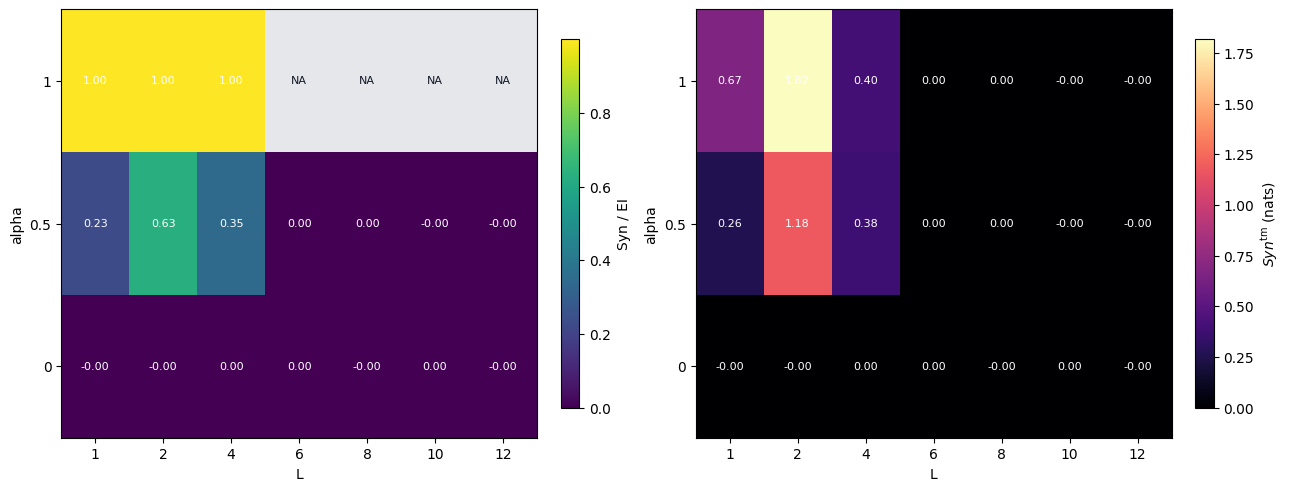

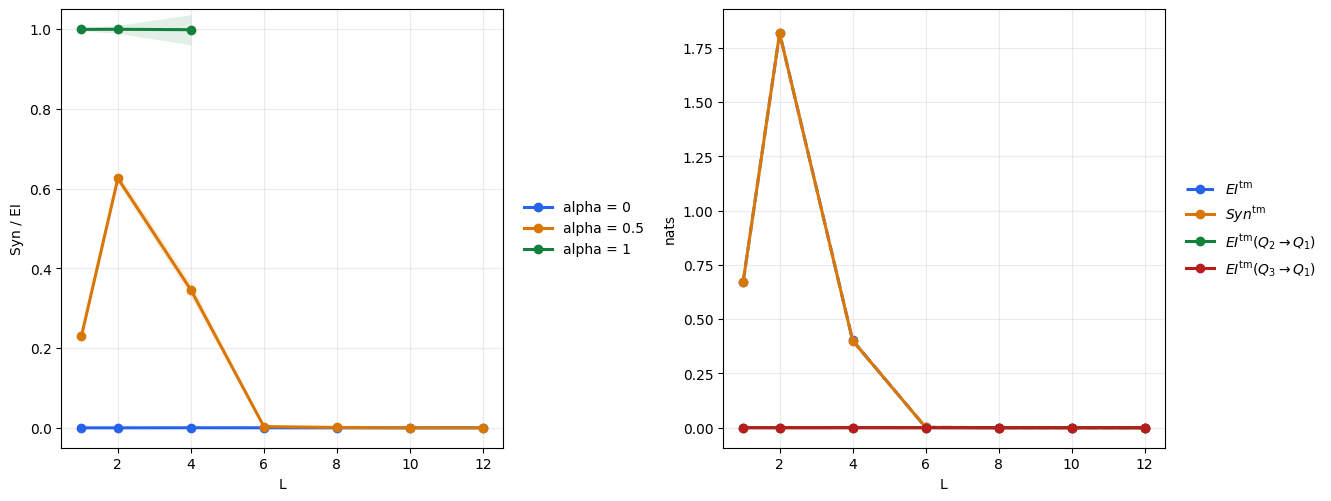

In [12]:
def plot_l_sweep_tm(summary_df: pd.DataFrame) -> tuple[Any, Any]:
    output_dir = PROJECT_ROOT / 'fig' / 'transport_map_mutual_information'
    output_dir.mkdir(parents=True, exist_ok=True)

    alpha_values = list(summary_df['alpha'].drop_duplicates())
    l_values = list(summary_df['L'].drop_duplicates())
    reliable_ratio_df = summary_df.copy()
    reliable_ratio_df['tm_syn_ratio_reliable'] = reliable_ratio_df['tm_syn_ratio'].where(reliable_ratio_df['tm_ei_mean'] >= 0.05)
    syn_ratio_grid = reliable_ratio_df.pivot(index='alpha', columns='L', values='tm_syn_ratio_reliable').loc[alpha_values, l_values]
    syn_grid = summary_df.pivot(index='alpha', columns='L', values='tm_syn_mean').loc[alpha_values, l_values]

    heatmap_fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8), constrained_layout=True)
    panels = [
        (axes[0], syn_ratio_grid, 'Syn / EI', 'viridis'),
        (axes[1], syn_grid, r'$Syn^{\mathrm{tm}}$ (nats)', 'magma'),
    ]
    for ax, grid, colorbar_label, cmap in panels:
        cmap_obj = plt.get_cmap(cmap).copy()
        cmap_obj.set_bad('#e5e7eb')
        image = ax.imshow(np.ma.masked_invalid(grid.to_numpy(dtype=float)), aspect='auto', origin='lower', cmap=cmap_obj)
        ax.set_xlabel('L')
        ax.set_ylabel('alpha')
        ax.set_xticks(np.arange(len(l_values)), labels=[f'{value:g}' for value in l_values])
        ax.set_yticks(np.arange(len(alpha_values)), labels=[f'{value:g}' for value in alpha_values])
        for row_index, alpha in enumerate(alpha_values):
            for col_index, L in enumerate(l_values):
                value = grid.loc[alpha, L]
                label = 'NA' if pd.isna(value) else f'{value:.2f}'
                text_color = '#111827' if pd.isna(value) else 'white'
                ax.text(col_index, row_index, label, ha='center', va='center', fontsize=8, color=text_color)
        heatmap_fig.colorbar(image, ax=ax, shrink=0.86, label=colorbar_label)

    heatmap_png = output_dir / 'tm_l_sensitivity_heatmap.png'
    heatmap_pdf = output_dir / 'tm_l_sensitivity_heatmap.pdf'
    heatmap_fig.savefig(heatmap_png, dpi=220, bbox_inches='tight')
    heatmap_fig.savefig(heatmap_pdf, bbox_inches='tight')

    line_fig, line_axes = plt.subplots(1, 2, figsize=(13.2, 4.9), constrained_layout=True)
    colors = {0.0: '#2563eb', 0.5: '#d97706', 1.0: '#15803d'}
    for alpha in alpha_values:
        part = summary_df.loc[summary_df['alpha'] == alpha].sort_values('L')
        color = colors.get(float(alpha), '#4b5563')
        reliable_part = part.copy()
        reliable_part['tm_syn_ratio_reliable'] = reliable_part['tm_syn_ratio'].where(reliable_part['tm_ei_mean'] >= 0.05)
        line_axes[0].plot(reliable_part['L'], reliable_part['tm_syn_ratio_reliable'], marker='o', linewidth=2.2, color=color, label=f'alpha = {alpha:g}')
        ratio_std = reliable_part['tm_syn_std'].to_numpy(dtype=float) / np.maximum(reliable_part['tm_ei_mean'].to_numpy(dtype=float), 1e-12)
        ratio_mean = reliable_part['tm_syn_ratio_reliable'].to_numpy(dtype=float)
        line_axes[0].fill_between(
            reliable_part['L'].to_numpy(dtype=float),
            np.maximum(0.0, ratio_mean - ratio_std),
            ratio_mean + ratio_std,
            color=color,
            alpha=0.12,
            linewidth=0,
        )
    line_axes[0].set_xlabel('L')
    line_axes[0].set_ylabel('Syn / EI')
    line_axes[0].set_ylim(-0.05, 1.05)
    line_axes[0].grid(alpha=0.25)
    line_axes[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    alpha_one = summary_df.loc[np.isclose(summary_df['alpha'], 1.0)].sort_values('L')
    component_specs = [
        ('tm_ei_mean', 'tm_ei_std', r'$EI^{\mathrm{tm}}$', '#2563eb', '--'),
        ('tm_syn_mean', 'tm_syn_std', r'$Syn^{\mathrm{tm}}$', '#d97706', '-'),
        ('tm_single_q2_mean', 'tm_single_q2_std', r'$EI^{\mathrm{tm}}(Q_2 \to Q_1)$', '#15803d', '-'),
        ('tm_single_q3_mean', 'tm_single_q3_std', r'$EI^{\mathrm{tm}}(Q_3 \to Q_1)$', '#b91c1c', '-'),
    ]
    x_values = alpha_one['L'].to_numpy(dtype=float)
    for mean_col, std_col, label, color, linestyle in component_specs:
        mean_values = alpha_one[mean_col].to_numpy(dtype=float)
        std_values = alpha_one[std_col].fillna(0.0).to_numpy(dtype=float)
        line_axes[1].plot(x_values, mean_values, marker='o', linewidth=2.2, linestyle=linestyle, color=color, label=label)
        line_axes[1].fill_between(x_values, mean_values - std_values, mean_values + std_values, color=color, alpha=0.10, linewidth=0)
    line_axes[1].set_xlabel('L')
    line_axes[1].set_ylabel('nats')
    line_axes[1].grid(alpha=0.25)
    line_axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    line_png = output_dir / 'tm_l_sensitivity_lines.png'
    line_pdf = output_dir / 'tm_l_sensitivity_lines.pdf'
    line_fig.savefig(line_png, dpi=220, bbox_inches='tight')
    line_fig.savefig(line_pdf, bbox_inches='tight')

    notes_path = output_dir / 'tm_l_sensitivity_notes.md'
    notes_path.write_text(
        '\n'.join(
            [
                '# TM L sensitivity notes',
                '',
                '- `tm_l_sweep_runs.csv` stores every repeat for each `(L, alpha)` setting.',
                '- `tm_l_sweep_summary.csv` stores mean and standard deviation summaries used by the figures.',
                '- The heatmap compares `Syn / EI` and absolute `Syn` over the `(alpha, L)` grid.',
                '- `Syn / EI` entries are marked `NA` when mean `EI` is below 0.05 nats because the ratio is numerically unstable.',
                '- The line figure shows how `Syn / EI` changes with `L`, and decomposes the pure nonlinear case `alpha = 1`.',
            ]
        ),
        encoding='utf-8',
    )

    manifest_path = output_dir / 'tm_l_sensitivity_manifest.json'
    manifest_path.write_text(
        json.dumps(
            {
                'notebook': 'exp/tm_nonlinear.ipynb',
                'l_values': [float(value) for value in l_values],
                'alpha_values': [float(value) for value in alpha_values],
                'runs_csv': 'tm_l_sweep_runs.csv',
                'summary_csv': 'tm_l_sweep_summary.csv',
                'figures': [heatmap_png.name, heatmap_pdf.name, line_png.name, line_pdf.name],
                'notes': notes_path.name,
            },
            ensure_ascii=False,
            indent=2,
        ),
        encoding='utf-8',
    )
    return heatmap_fig, line_fig


plot_l_sweep_tm(l_tm_summary)


## L sweep 的初步读法

这组图主要回答：协同估计是否只由 `alpha` 决定，还是也依赖干预分布的覆盖范围。若 `alpha = 0` 在所有 `L` 下仍保持低 `Syn^{tm}`，说明单源结构没有因为扩大干预范围而被系统性误判为协同。若 `alpha = 1` 的 `Syn/EI` 随 `L` 改变，说明 TM 估计不仅在读出结构项，还受到 `sin(Q_2^nQ_3^n)` 在当前干预盒中被采样到的局部形状影响。

需要特别注意小 `L` 区间：当 `L` 很小时，`sin(Q_2^nQ_3^n) \approx Q_2^nQ_3^n`，联合项更像平滑乘积；当 `L` 变大时，目标进入多周期振荡区，低阶 lifted affine TM 可能把一部分可解释结构压缩掉。因此 `L` sweep 不是单纯的样本尺度检查，而是在检查干预范围、非线性周期覆盖和 TM 特征族之间的相互作用。


## 固定 alpha 的噪声强度扫描

这一组实验固定干预范围 `L`，只增强 `Q_1` 更新方程里的外部噪声，分别检查 `alpha = 0.0, 0.5, 1.0` 时整体 `EI^{tm}`、单源 `EI^{tm}` 和 `Syn^{tm}` 如何退化。这样可以区分两件事：协同结构本身是否存在，以及该结构在目标变量被噪声污染后还能被 TM 稳定读出多少。

In [15]:
NOISE_SWEEP_ALPHA_VALUES = (0.0, 0.5, 1.0)
NOISE_STD_VALUES = (0.0, 0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0)


def run_fixed_alpha_noise_sweep_tm(
    *,
    alpha_values: tuple[float, ...] = NOISE_SWEEP_ALPHA_VALUES,
    noise_std_values: tuple[float, ...] = NOISE_STD_VALUES,
    n_samples: int = N_SAMPLES,
    repeats: int = REPEATS,
    L: float = INPUT_BOX_WIDTH,
    seed: int = SEED + 80000,
) -> pd.DataFrame:
    rows: list[dict[str, float | int]] = []
    for alpha_index, alpha in enumerate(alpha_values):
        for noise_index, q1_noise_std in enumerate(noise_std_values):
            for repeat in range(repeats):
                run_seed = seed + 10000 * alpha_index + 1000 * noise_index + repeat
                df = simulate_alpha_case_intervention(
                    alpha=float(alpha),
                    n_samples=n_samples,
                    L=L,
                    q1_noise_std=float(q1_noise_std),
                    seed=run_seed,
                )
                tm_metrics = estimate_tm_alpha_metrics(df)
                rows.append(
                    {
                        'alpha': float(alpha),
                        'q1_noise_std': float(q1_noise_std),
                        'repeat': int(repeat),
                        'L': float(L),
                        'tm_ei': tm_metrics['tm_ei'],
                        'tm_syn': tm_metrics['tm_syn'],
                        'tm_single_q2': tm_metrics['tm_single_q2'],
                        'tm_single_q3': tm_metrics['tm_single_q3'],
                    }
                )
    return pd.DataFrame(rows)


def summarize_fixed_alpha_noise_sweep_tm(results_df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        results_df.groupby(['alpha', 'q1_noise_std', 'L'], as_index=False)
        .agg(
            tm_ei_mean=('tm_ei', 'mean'),
            tm_ei_std=('tm_ei', 'std'),
            tm_syn_mean=('tm_syn', 'mean'),
            tm_syn_std=('tm_syn', 'std'),
            tm_single_q2_mean=('tm_single_q2', 'mean'),
            tm_single_q2_std=('tm_single_q2', 'std'),
            tm_single_q3_mean=('tm_single_q3', 'mean'),
            tm_single_q3_std=('tm_single_q3', 'std'),
        )
        .sort_values(['alpha', 'q1_noise_std'])
        .reset_index(drop=True)
    )
    summary['tm_syn_ratio'] = np.where(
        np.abs(summary['tm_ei_mean']) > 1e-12,
        summary['tm_syn_mean'] / summary['tm_ei_mean'],
        np.nan,
    )
    summary['tm_single_q2_ratio'] = np.where(
        np.abs(summary['tm_ei_mean']) > 1e-12,
        summary['tm_single_q2_mean'] / summary['tm_ei_mean'],
        np.nan,
    )
    summary['tm_single_q3_ratio'] = np.where(
        np.abs(summary['tm_ei_mean']) > 1e-12,
        summary['tm_single_q3_mean'] / summary['tm_ei_mean'],
        np.nan,
    )
    return summary


noise_output_dir = PROJECT_ROOT / 'fig' / 'transport_map_mutual_information'
noise_output_dir.mkdir(parents=True, exist_ok=True)
noise_runs_path = noise_output_dir / 'tm_fixed_alpha_noise_sweep_runs.csv'
noise_summary_path = noise_output_dir / 'tm_fixed_alpha_noise_sweep_summary.csv'

if noise_summary_path.exists() and noise_runs_path.exists():
    fixed_alpha_noise_results = pd.read_csv(noise_runs_path)
    fixed_alpha_noise_summary = pd.read_csv(noise_summary_path)
else:
    fixed_alpha_noise_results = run_fixed_alpha_noise_sweep_tm()
    fixed_alpha_noise_summary = summarize_fixed_alpha_noise_sweep_tm(fixed_alpha_noise_results)
    fixed_alpha_noise_results.to_csv(noise_runs_path, index=False)
    fixed_alpha_noise_summary.to_csv(noise_summary_path, index=False)

fixed_alpha_noise_summary

,alpha,q1_noise_std,L,tm_ei_mean,tm_ei_std,tm_syn_mean,tm_syn_std,tm_single_q2_mean,tm_single_q2_std,tm_single_q3_mean,tm_single_q3_std,tm_syn_ratio,tm_single_q2_ratio,tm_single_q3_ratio
0,0.0,0.00,2.0,6.516295,0.007206,-0.000250,1.740405e-11,6.516545,0.007206,0.000000e+00,0.000000e+00,-0.000038,1.000038,0.000000e+00
1,0.0,0.02,2.0,3.361797,0.009537,-0.000007,2.714158e-04,3.361802,0.009378,1.790727e-06,3.581453e-06,-0.000002,1.000001,5.326694e-07
2,0.0,0.05,2.0,2.460290,0.006187,-0.000044,5.041170e-04,2.460186,0.006344,1.477200e-04,2.954400e-04,-0.000018,0.999958,6.004171e-05
3,0.0,0.10,2.0,1.765681,0.011670,-0.000033,2.928768e-04,1.765714,0.011386,0.000000e+00,0.000000e+00,-0.000019,1.000019,0.000000e+00
4,0.0,0.20,2.0,1.125334,0.009493,-0.000228,3.197708e-04,1.125322,0.009432,2.399796e-04,2.762611e-04,-0.000203,0.999989,2.132518e-04
5,0.0,0.40,2.0,0.564089,0.018629,-0.000018,2.404814e-04,0.564100,0.018433,6.864539e-06,1.372908e-05,-0.000032,1.000020,1.216925e-05
6,0.0,0.60,2.0,0.323055,0.011544,-0.000092,4.241131e-05,0.323063,0.011685,8.457719e-05,1.691544e-04,-0.000285,1.000023,2.618042e-04
7,0.0,0.80,2.0,0.209921,0.005842,-0.000170,3.017624e-04,0.210046,0.005937,4.482015e-05,8.964029e-05,-0.000810,1.000597,2.135099e-04
8,0.0,1.00,2.0,0.145887,0.003287,0.000279,2.837002e-04,0.145479,0.003084,1.280235e-04,1.509696e-04,0.001913,0.997210,8.775554e-04
9,0.5,0.00,2.0,3.959919,0.016934,3.228067,1.080173e-02,0.731757,0.010137,9.504027e-05,1.900805e-04,0.815185,0.184791,2.400056e-05


(<Figure size 1560x480 with 3 Axes>, <Figure size 1560x480 with 3 Axes>)

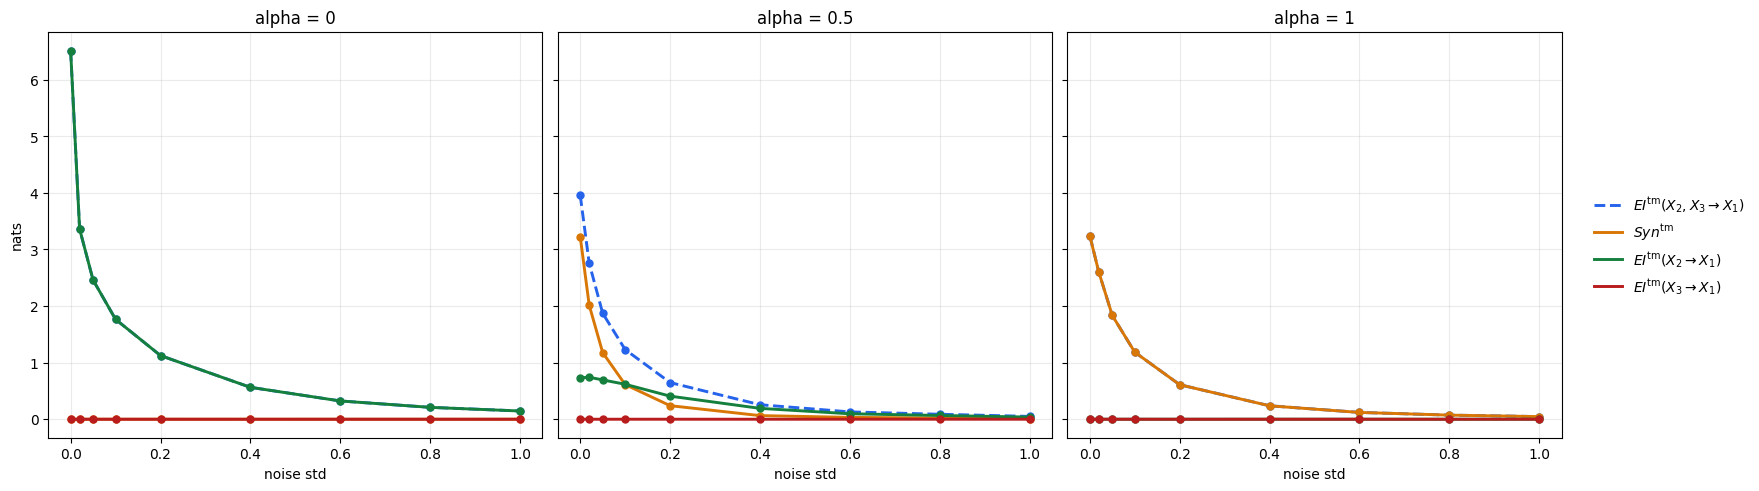

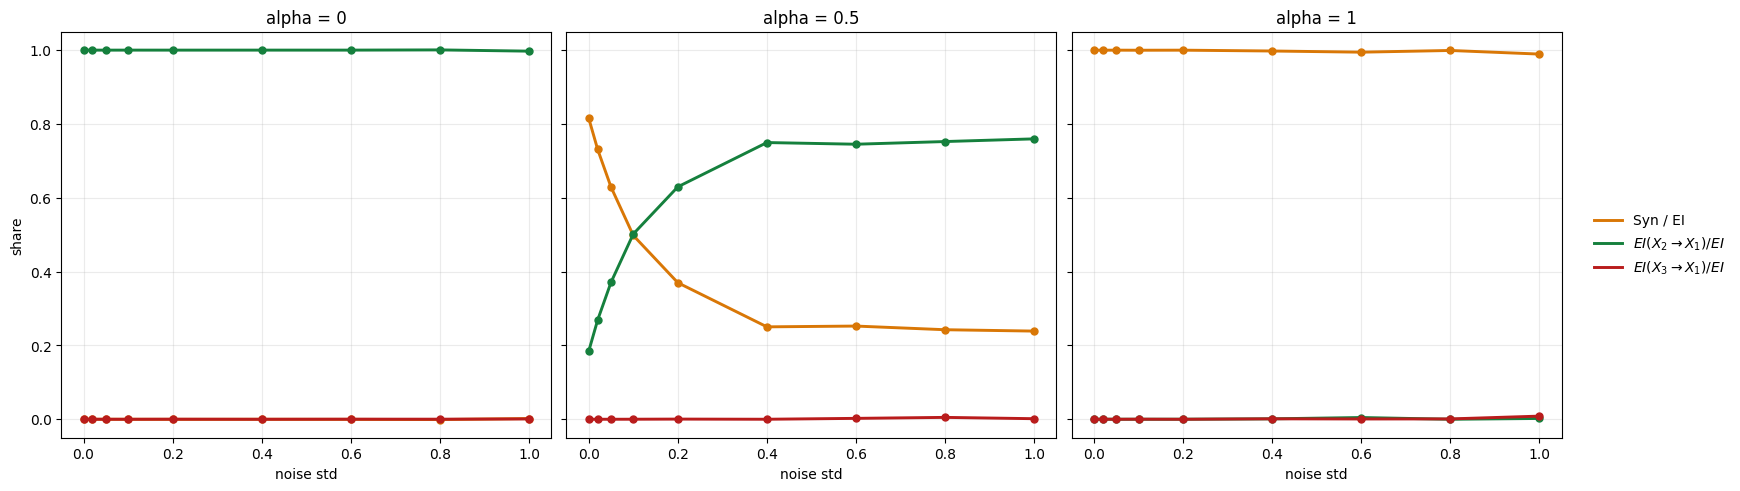

In [16]:
def plot_fixed_alpha_noise_sweep_tm(summary_df: pd.DataFrame) -> tuple[Any, Any]:
    from matplotlib.lines import Line2D

    output_dir = PROJECT_ROOT / 'fig' / 'transport_map_mutual_information'
    output_dir.mkdir(parents=True, exist_ok=True)

    alpha_values = list(summary_df['alpha'].drop_duplicates())
    colors = {
        'tm_ei': '#2563eb',
        'tm_syn': '#d97706',
        'tm_single_q2': '#15803d',
        'tm_single_q3': '#b91c1c',
    }
    component_specs = [
        ('tm_ei_mean', 'tm_ei_std', r'$EI^{\mathrm{tm}}(X_2, X_3 \to X_1)$', colors['tm_ei'], '--'),
        ('tm_syn_mean', 'tm_syn_std', r'$Syn^{\mathrm{tm}}$', colors['tm_syn'], '-'),
        ('tm_single_q2_mean', 'tm_single_q2_std', r'$EI^{\mathrm{tm}}(X_2 \to X_1)$', colors['tm_single_q2'], '-'),
        ('tm_single_q3_mean', 'tm_single_q3_std', r'$EI^{\mathrm{tm}}(X_3 \to X_1)$', colors['tm_single_q3'], '-'),
    ]

    decomp_fig, decomp_axes = plt.subplots(1, len(alpha_values), figsize=(15.6, 4.8), sharey=True, constrained_layout=True)
    if len(alpha_values) == 1:
        decomp_axes = [decomp_axes]
    for ax, alpha in zip(decomp_axes, alpha_values):
        part = summary_df.loc[np.isclose(summary_df['alpha'], alpha)].sort_values('q1_noise_std')
        x_values = part['q1_noise_std'].to_numpy(dtype=float)
        for mean_col, std_col, label, color, linestyle in component_specs:
            mean_values = part[mean_col].to_numpy(dtype=float)
            std_values = part[std_col].fillna(0.0).to_numpy(dtype=float)
            ax.plot(x_values, mean_values, marker='o', markersize=5.0, linewidth=2.1, linestyle=linestyle, color=color, label=label)
            ax.fill_between(x_values, mean_values - std_values, mean_values + std_values, color=color, alpha=0.10, linewidth=0)
        ax.set_title(f'alpha = {alpha:g}')
        ax.set_xlabel('noise std')
        ax.grid(alpha=0.25)
    decomp_axes[0].set_ylabel('nats')
    decomp_handles = [
        Line2D([0], [0], color=color, linestyle=linestyle, linewidth=2.1, label=label)
        for _, _, label, color, linestyle in component_specs
    ]
    decomp_fig.legend(handles=decomp_handles, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)

    share_fig, share_axes = plt.subplots(1, len(alpha_values), figsize=(15.6, 4.8), sharey=True, constrained_layout=True)
    if len(alpha_values) == 1:
        share_axes = [share_axes]
    ratio_specs = [
        ('tm_syn_ratio', 'Syn / EI', colors['tm_syn']),
        ('tm_single_q2_ratio', r'$EI(X_2 \rightarrow X_1) / EI$', colors['tm_single_q2']),
        ('tm_single_q3_ratio', r'$EI(X_3 \rightarrow X_1) / EI$', colors['tm_single_q3']),
    ]
    for ax, alpha in zip(share_axes, alpha_values):
        part = summary_df.loc[np.isclose(summary_df['alpha'], alpha)].sort_values('q1_noise_std')
        x_values = part['q1_noise_std'].to_numpy(dtype=float)
        for ratio_col, label, color in ratio_specs:
            ax.plot(x_values, part[ratio_col], marker='o', markersize=5.0, linewidth=2.1, color=color, label=label)
        ax.set_title(f'alpha = {alpha:g}')
        ax.set_xlabel('noise std')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(alpha=0.25)
    share_axes[0].set_ylabel('share')
    share_handles = [Line2D([0], [0], color=color, linewidth=2.1, label=label) for _, label, color in ratio_specs]
    share_fig.legend(handles=share_handles, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)

    decomp_png = output_dir / 'tm_fixed_alpha_noise_sweep_decomposition.png'
    decomp_pdf = output_dir / 'tm_fixed_alpha_noise_sweep_decomposition.pdf'
    share_png = output_dir / 'tm_fixed_alpha_noise_sweep_share_ratio.png'
    share_pdf = output_dir / 'tm_fixed_alpha_noise_sweep_share_ratio.pdf'
    decomp_fig.savefig(decomp_png, dpi=220, bbox_inches='tight')
    decomp_fig.savefig(decomp_pdf, bbox_inches='tight')
    share_fig.savefig(share_png, dpi=220, bbox_inches='tight')
    share_fig.savefig(share_pdf, bbox_inches='tight')

    notes_path = output_dir / 'tm_fixed_alpha_noise_sweep_notes.md'
    notes_path.write_text(
        '\n'.join(
            [
                '# Fixed-alpha TM noise sweep notes',
                '',
                '- `tm_fixed_alpha_noise_sweep_runs.csv` stores every repeat for each `(alpha, q1_noise_std)` setting.',
                '- `tm_fixed_alpha_noise_sweep_summary.csv` stores mean and standard deviation summaries used by the figures.',
                '- The decomposition figure compares joint EI, synergy, and two single-source EI estimates as target noise increases.',
                '- The share figure compares the relative contribution of synergy and single-source EI under the same noise sweep.',
            ]
        ),
        encoding='utf-8',
    )

    manifest_path = output_dir / 'tm_fixed_alpha_noise_sweep_manifest.json'
    manifest_path.write_text(
        json.dumps(
            {
                'notebook': 'exp/tm_nonlinear.ipynb',
                'alpha_values': [float(value) for value in alpha_values],
                'noise_std_values': [float(value) for value in summary_df['q1_noise_std'].drop_duplicates()],
                'runs_csv': 'tm_fixed_alpha_noise_sweep_runs.csv',
                'summary_csv': 'tm_fixed_alpha_noise_sweep_summary.csv',
                'figures': [decomp_png.name, decomp_pdf.name, share_png.name, share_pdf.name],
                'notes': notes_path.name,
            },
            ensure_ascii=False,
            indent=2,
        ),
        encoding='utf-8',
    )
    return decomp_fig, share_fig


plot_fixed_alpha_noise_sweep_tm(fixed_alpha_noise_summary)


## 噪声扫描的初步读法

这组扫描的核心预期是：随着 `q1_noise_std` 增强，所有 `EI^{tm}` 绝对量都会下降，因为目标变量中可由干预源解释的部分被外部噪声稀释。三条 `alpha` 线之间的差别更关键：`alpha = 0` 应主要表现为 `Q_2` 的单源贡献随噪声衰减，而 `Syn^{tm}` 保持低位；`alpha = 1` 应主要表现为协同项随噪声衰减；`alpha = 0.5` 则应位于二者之间，既保留单源解释，也保留一部分联合解释。

因此，这里不只看 `Syn^{tm}` 的绝对值，还要看 `Syn / EI`。如果噪声增强时 `Syn^{tm}` 和整体 `EI^{tm}` 同步下降，但 `Syn / EI` 在 `alpha = 1` 下仍高于 `alpha = 0`，说明 TM 读出的协同结构比例仍然稳定；如果比例也快速坍缩，则说明目标噪声会改变 TM 对结构类型的分解，而不只是降低可解释信息总量。

## 如何解读这组结果

- 如果 `alpha = 0` 时 `Syn^tm` 接近 `0`，说明 `TM` 没有把纯单源加性结构误判成协同。
- 如果 `alpha` 从 `0` 到 `1` 递增时 `Syn^tm` 持续上升，说明 `TM` 估计出的协同强度能跟随我们注入的联合项强度变化。
- `EI^{tm}(Q_2 \to Q_1)` 随 `alpha` 下降是预期现象，因为原本由单源 `Q_2` 提供的可解释信息正在被联合乘积项替代。
- `EI^{tm}(Q_3 \to Q_1)` 可能一直很小，这并不矛盾：`Q_3` 在这个案例里主要通过和 `Q_2` 的联合关系发挥作用，而不是单独决定目标。
- 整体 `EI^{tm}` 不一定单调增加；更关键的是 `Syn / EI` 是否抬升，以及单源占比是否向协同占比让位。
